In [0]:
# Description: This program uses an artificial recurrent neural network called Long Short Term Memory (LSTM) 
#              to predict the closing stock price of a corporation (Apple Inc.) using the past 60 day stock price.

In [0]:
#Import the libraries
import math
import pandas_datareader as web
import numpy as np
import pandas as pd
from sklearn.preprocessing import MinMaxScaler
from keras.models import Sequential
from keras.layers import Dense, LSTM
import matplotlib.pyplot as plt
plt.style.use('fivethirtyeight')

In [57]:
#Get the stock quote 
df = web.DataReader('AAPL', data_source='yahoo', start='2015-01-01', end='2020-06-10') 
#Show the data 
df

,High,Low,Open,Close,Volume,Adj Close
Date,,,,,,
2015-01-02,111.440002,107.349998,111.389999,109.330002,53204600.0,99.945885
2015-01-05,108.650002,105.410004,108.290001,106.250000,64285500.0,97.130241
2015-01-06,107.430000,104.629997,106.540001,106.260002,65797100.0,97.139420
2015-01-07,108.199997,106.699997,107.199997,107.750000,40105900.0,98.501518
2015-01-08,112.150002,108.699997,109.230003,111.889999,59364500.0,102.286186
...,...,...,...,...,...,...
2020-06-04,325.619995,320.779999,324.390015,322.320007,21890100.0,322.320007
2020-06-05,331.750000,323.230011,323.350006,331.500000,34312600.0,331.500000
2020-06-08,333.600006,327.320007,330.250000,333.459991,23913600.0,333.459991


In [58]:
df.shape

(1369, 6)

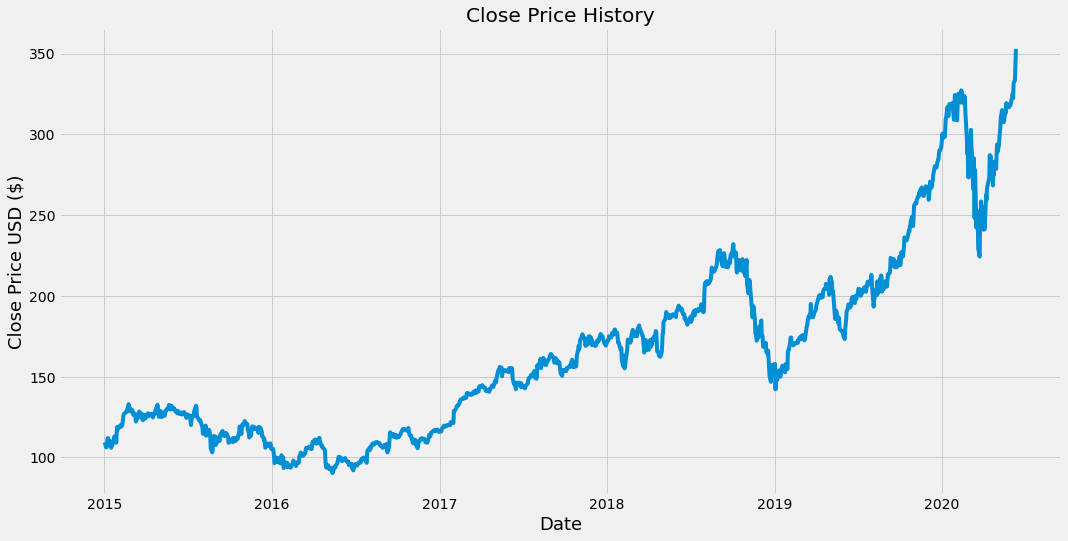

In [59]:
#Visualize the closing price history
plt.figure(figsize=(16,8))
plt.title('Close Price History')
plt.plot(df['Close'])
plt.xlabel('Date',fontsize=18)
plt.ylabel('Close Price USD ($)',fontsize=18)
plt.show()

In [0]:
#Create a new dataframe with only the 'Close' column
data = df.filter(['Close']) #Converting the dataframe to a numpy array
dataset = data.values #Get /Compute the number of rows to train the model on
training_data_len = math.ceil( len(dataset) *.8) 

In [61]:
#Scale the all of the data to be values between 0 and 1 
scaler = MinMaxScaler(feature_range=(0, 1)) 
scaled_data = scaler.fit_transform(dataset)
scaled_data

array([[0.07234288],
       [0.06060954],
       [0.06064764],
       ...,
       [0.92617141],
       [0.96628569],
       [1.        ]])

In [0]:
#Create the scaled training data set 
train_data = scaled_data[0:training_data_len  , : ] #Split the data into x_train and y_train data sets
x_train=[]
y_train = []
for i in range(60,len(train_data)):
    x_train.append(train_data[i-60:i,0])
    y_train.append(train_data[i,0])

In [0]:
#Convert x_train and y_train to numpy arrays
x_train, y_train = np.array(x_train), np.array(y_train)

In [0]:
#Reshape the data into the shape accepted by the LSTM
x_train = np.reshape(x_train, (x_train.shape[0],x_train.shape[1],1))

In [0]:
#Build the LSTM network model
model = Sequential()
model.add(LSTM(units=50, return_sequences=True,input_shape=(x_train.shape[1],1)))
model.add(LSTM(units=50, return_sequences=False))
model.add(Dense(units=25))
model.add(Dense(units=1))

In [0]:
#Compile the model
model.compile(optimizer='adam', loss='mean_squared_error')

In [67]:
#Train the model
model.fit(x_train, y_train, batch_size=1, epochs=1)

Epoch 1/1
1036/1036 [==============================] - 44s 43ms/step - loss: 0.0010


In [0]:
#Test data set
test_data = scaled_data[training_data_len - 60: , : ] #Create the x_test and y_test data sets
x_test = []
y_test =  dataset[training_data_len : , : ] #Get all of the rows from index 1603 to the rest and all of the columns (in this case it's only column 'Close'), so 2003 - 1603 = 400 rows of data
for i in range(60,len(test_data)):
    x_test.append(test_data[i-60:i,0])

In [0]:
#Convert x_test to a numpy array 
x_test = np.array(x_test)

In [0]:
#Reshape the data into the shape accepted by the LSTM 3D [number of samples, number of time steps, and number of features].
x_test = np.reshape(x_test, (x_test.shape[0],x_test.shape[1],1))

In [0]:
#Getting the models predicted price values
predictions = model.predict(x_test) 
predictions = scaler.inverse_transform(predictions) #Undo scaling

In [73]:
#Calculate/Get the value of RMSE
#rmse=np.sqrt(np.mean(((predictions- y_test)**2)))

#You can use the following statements to calculate RMSE:
#1. rmse =np.sqrt(np.mean(((predictions- y_test)**2)))
#2. rmse = np.sqrt(np.mean(np.power((np.array(y_test)-np.array(predictions)),2)))
#3. rmse = np.sqrt(((predictions - y_test) ** 2).mean())

rmse=np.sqrt(np.mean((predictions- y_test)**2))
rmse

12.393534863025533

/usr/local/lib/python3.6/dist-packages/ipykernel_launcher.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  after removing the cwd from sys.path.


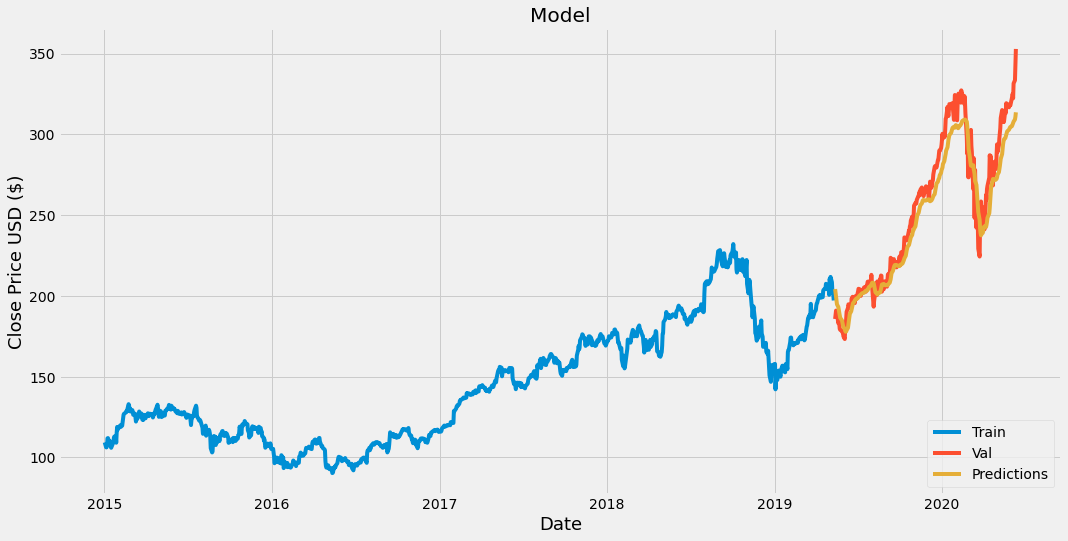

In [75]:
#Plot/Create the data for the graph
train = data[:training_data_len]
valid = data[training_data_len:]
valid['Predictions'] = predictions#Visualize the data
plt.figure(figsize=(16,8))
plt.title('Model')
plt.xlabel('Date', fontsize=18)
plt.ylabel('Close Price USD ($)', fontsize=18)
plt.plot(train['Close'])
plt.plot(valid[['Close', 'Predictions']])
plt.legend(['Train', 'Val', 'Predictions'], loc='lower right')
plt.show()

In [76]:
#Show the valid and predicted prices
valid

,Close,Predictions
Date,,
2019-05-13,185.720001,204.211151
2019-05-14,188.660004,201.723862
2019-05-15,190.919998,199.089462
2019-05-16,190.080002,196.792908
2019-05-17,189.000000,194.812881
...,...,...
2020-06-04,322.320007,307.191620
2020-06-05,331.500000,307.841644
2020-06-08,333.459991,309.200165


In [77]:
#Get the quote [predicted price]
apple_quote = web.DataReader('AAPL', data_source='yahoo', start='2015-01-01', end='2020-06-10') #Create a new dataframe
new_df = apple_quote.filter(['Close']) #Get teh last 60 day closing price 
last_60_days = new_df[-60:].values #Scale the data to be values between 0 and 1
last_60_days_scaled = scaler.transform(last_60_days) #Create an empty list
X_test = [] #Append teh past 60 days
X_test.append(last_60_days_scaled) #Convert the X_test data set to a numpy array
X_test = np.array(X_test) #Reshape the data
X_test = np.reshape(X_test, (X_test.shape[0], X_test.shape[1], 1)) #Get the predicted scaled price
pred_price = model.predict(X_test) #undo the scaling 
pred_price = scaler.inverse_transform(pred_price)
print(pred_price)

[[317.40436]]


In [78]:
#Get the quote [real price]
apple_quote2 = web.DataReader('AAPL', data_source='yahoo', start='2020-06-11', end='2020-06-11')
print(apple_quote2['Close'])

Date
2020-06-10    352.839996
Name: Close, dtype: float64
